/tmp/ipykernel_16627/2532851890.py:30: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)
/tmp/ipykernel_16627/2532851890.py:31: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

✅ Дані успішно очищено! Кількість пропусків: 0
--------------------------------------------------


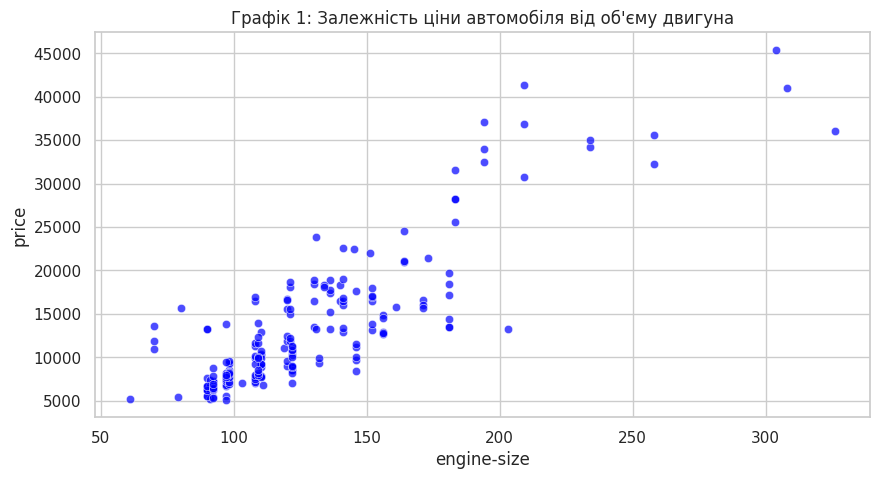

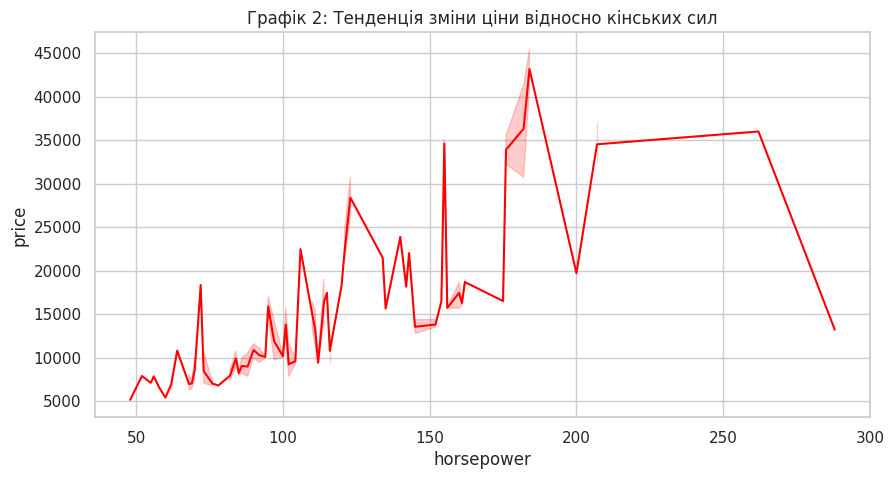

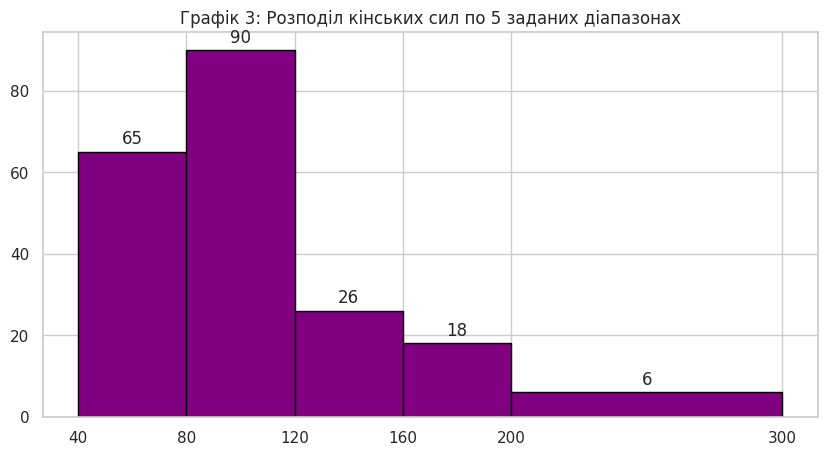

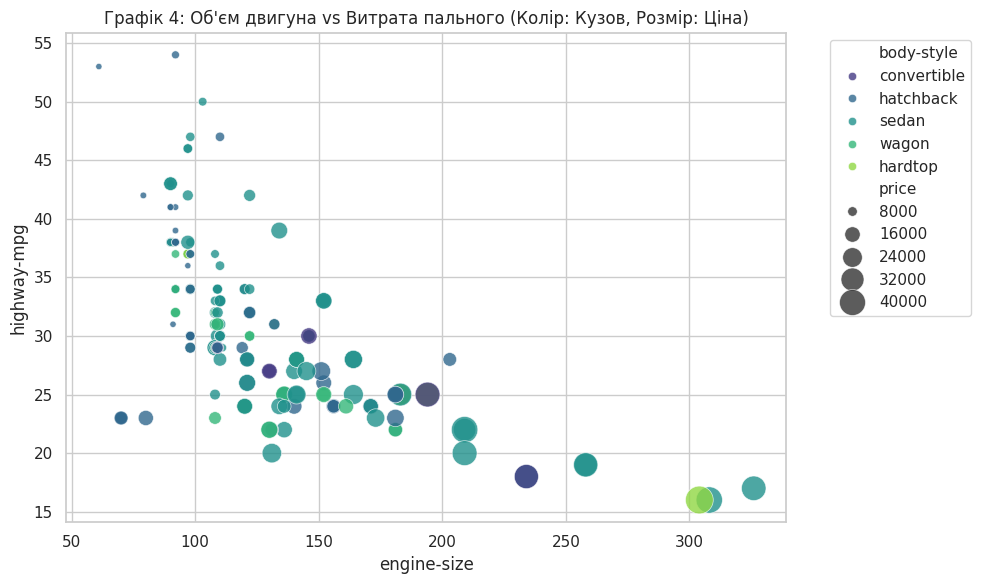

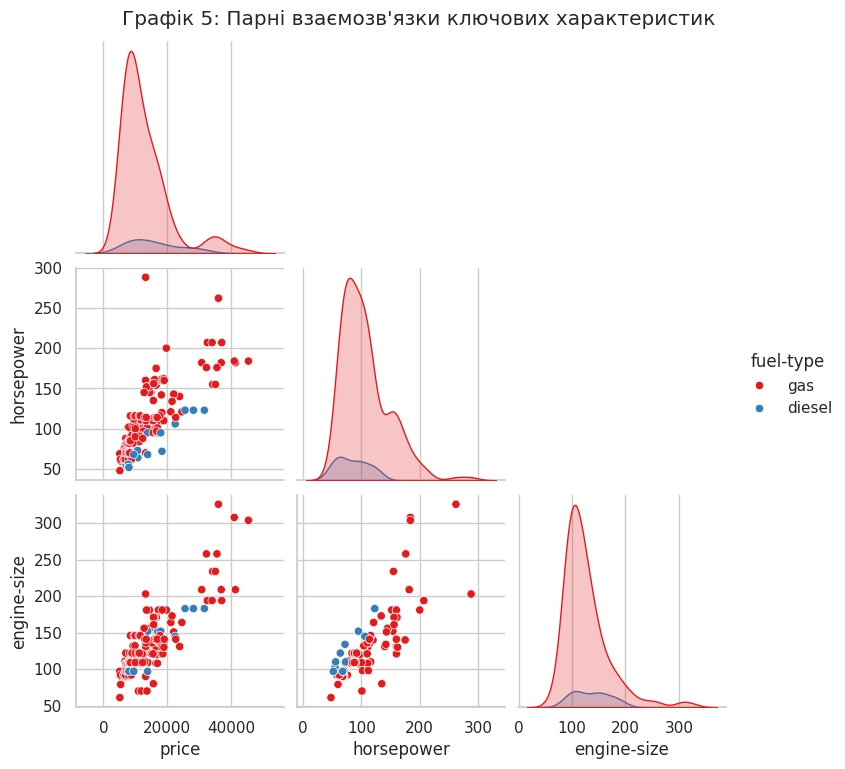

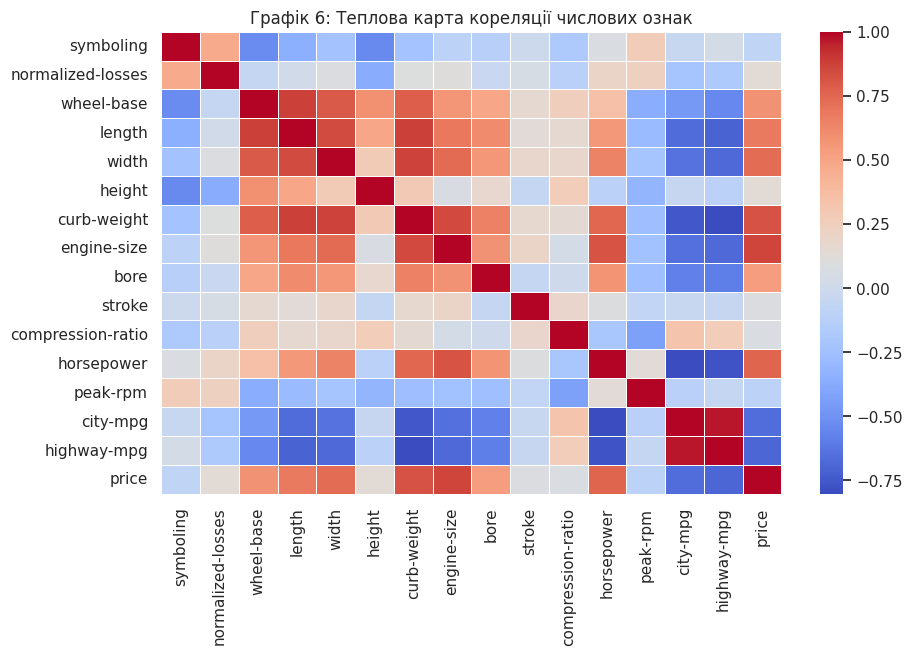

In [1]:
# Імпорт необхідних бібліотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Налаштування гарного стилю для графіків
sns.set_theme(style="whitegrid")

# 1. Завантаження даних
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/autos/imports-85.data"
columns = ["symboling", "normalized-losses", "make", "fuel-type", "aspiration",
           "num-of-doors", "body-style", "drive-wheels", "engine-location",
           "wheel-base", "length", "width", "height", "curb-weight",
           "engine-type", "num-of-cylinders", "engine-size", "fuel-system",
           "bore", "stroke", "compression-ratio", "horsepower", "peak-rpm",
           "city-mpg", "highway-mpg", "price"]
df = pd.read_csv(url, names=columns)

# 2. Очищення даних
# Замінюємо знаки питання на порожні значення (NaN)
df.replace("?", np.nan, inplace=True)

# Переводимо колонки в числовий формат
numeric_cols = ["normalized-losses", "bore", "stroke", "horsepower", "peak-rpm", "price"]
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric)

# Заповнюємо пропуски середніми значеннями
for col in numeric_cols:
    df[col].fillna(df[col].mean(), inplace=True)
df["num-of-doors"].fillna(df["num-of-doors"].mode()[0], inplace=True)

print("✅ Дані успішно очищено! Кількість пропусків:", df.isnull().sum().max())
print("-" * 50)

# 3. Візуалізація

# Графік 1: Залежність ціни від об'єму двигуна (Scatter plot)
plt.figure(figsize=(10, 5))
sns.scatterplot(x='engine-size', y='price', data=df, color='blue', alpha=0.7)
plt.title('Графік 1: Залежність ціни автомобіля від об\'єму двигуна')
plt.show()

# Графік 2: Тенденція зміни ціни (Line plot)
df_sorted = df.sort_values(by='horsepower')
plt.figure(figsize=(10, 5))
sns.lineplot(x='horsepower', y='price', data=df_sorted, color='red')
plt.title('Графік 2: Тенденція зміни ціни відносно кінських сил')
plt.show()

# Графік 3: Гістограма по 5 діапазонах
plt.figure(figsize=(10, 5))
custom_bins = [40, 80, 120, 160, 200, 300]
counts, edges, bars = plt.hist(df['horsepower'], bins=custom_bins, color='purple', edgecolor='black')
plt.title('Графік 3: Розподіл кінських сил по 5 заданих діапазонах')
plt.xticks(custom_bins)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, int(yval), ha='center', va='bottom')
plt.show()

# Графік 4: Багатовимірна візуалізація (з Medium)
plt.figure(figsize=(10, 6))
sns.scatterplot(x='engine-size', y='highway-mpg', hue='body-style', size='price', sizes=(20, 400), data=df, palette='viridis', alpha=0.8)
plt.title('Графік 4: Об\'єм двигуна vs Витрата пального (Колір: Кузов, Розмір: Ціна)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Графік 5: Парні взаємозв'язки (Pairplot)
subset_cols = ['price', 'horsepower', 'engine-size', 'fuel-type']
sns.pairplot(df[subset_cols], hue='fuel-type', palette='Set1', corner=True)
plt.suptitle('Графік 5: Парні взаємозв\'язки ключових характеристик', y=1.02)
plt.show()

# Графік 6: Теплова карта кореляції (Корисна інфа про датасет)
plt.figure(figsize=(10, 6))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Графік 6: Теплова карта кореляції числових ознак')
plt.show()